Food Delivery Order History Data innehåller 21321 historiska beställningar från diverse olika restauranger och fångar viktiga detaljer om kundpreferenser, ordertrender, prissättning, samt leveransprestanda.


In [1]:
import pandas as pd
import numpy as np

import os
os.environ['OMP_NUM_THREADS'] = '1'

In [2]:
df = pd.read_csv("data/order_history_kaggle_data.csv")

print("df.info")
print(df.info())
print("df.describe")
print(df.describe())
print("df.head")
print(df.head())

print(f"Före rengöring: {len(df)} rader")
print(f"Saknade värden:\n{df.isnull().sum()}")



df.info
<class 'pandas.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 29 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Restaurant ID                                       21321 non-null  int64  
 1   Restaurant name                                     21321 non-null  str    
 2   Subzone                                             21321 non-null  str    
 3   City                                                21321 non-null  str    
 4   Order ID                                            21321 non-null  int64  
 5   Order Placed At                                     21321 non-null  str    
 6   Order Status                                        21321 non-null  str    
 7   Delivery                                            21321 non-null  str    
 8   Distance                                            21321 non-null  str    
 9 

In [3]:
# Förstå datan bättre innan vi bygger features
print(df['Order Status'].value_counts())
print(df['Delivery'].value_counts())  
print(df['Order Ready Marked'].value_counts().head(20))
print(df['Distance'].value_counts().head(10))
print(f"Unika kunder: {df['Customer ID'].nunique()}")
print(f"Unika restauranger: {df['Restaurant name'].nunique()}")
print(f"Datumspann: {df['Order Placed At'].min()} → {df['Order Placed At'].max()}")


print(df['Order Placed At'].sort_values().head(5))
print(df['Order Placed At'].sort_values().tail(5))

Order Status
Delivered           21131
Rejected              158
Returned               25
Return cancelled        3
Picked up               3
Timed out               1
Name: count, dtype: int64
Delivery
Zomato Delivery    21321
Name: count, dtype: int64
Order Ready Marked
Correctly      19087
Incorrectly     1895
Missed           339
Name: count, dtype: int64
Distance
2km     3558
1km     3346
3km     3212
4km     2410
5km     2140
6km     2112
7km     1282
9km      767
8km      709
<1km     649
Name: count, dtype: int64
Unika kunder: 11607
Unika restauranger: 6
Datumspann: 01:00 AM, December 08 2024 → 12:59 PM, October 30 2024
13571    01:00 AM, December 08 2024
18087     01:00 AM, January 10 2025
19129     01:00 AM, January 19 2025
21315     01:00 AM, January 26 2025
20577     01:00 AM, January 28 2025
Name: Order Placed At, dtype: str
6237    12:59 PM, October 16 2024
6874    12:59 PM, October 19 2024
7882    12:59 PM, October 24 2024
6969    12:59 PM, October 26 2024
7678    12:59

In [4]:
# Kolla exakt hur några datum ser ut
print(df['Order Placed At'].head(10).tolist())

# Datumformatet ser verkligen skumt ut

# Prova parsa manuellt med rätt format
df['Order Placed At'] = pd.to_datetime(
    df['Order Placed At'],
    format='%I:%M %p, %B %d %Y'
)

# Kontrollera att det funkade bra
print(df['Order Placed At'].dtype)
print(df['Order Placed At'].head(3))

['11:38 PM, September 10 2024', '11:34 PM, September 10 2024', '03:52 PM, September 10 2024', '03:45 PM, September 10 2024', '03:04 PM, September 10 2024', '12:28 PM, September 10 2024', '12:03 AM, September 10 2024', '10:54 PM, September 09 2024', '10:51 PM, September 09 2024', '03:22 PM, September 09 2024']
datetime64[us]
0   2024-09-10 23:38:00
1   2024-09-10 23:34:00
2   2024-09-10 15:52:00
Name: Order Placed At, dtype: datetime64[us]


In [5]:
print(df['Order Placed At'].dt.year.value_counts())
print(df['Order Placed At'].dt.month.value_counts().sort_index())
print(f"Tidigast: {df['Order Placed At'].min()}")
print(f"Senast:   {df['Order Placed At'].max()}")

Order Placed At
2024    17310
2025     4011
Name: count, dtype: int64
Order Placed At
1     4011
9     4241
10    4277
11    4491
12    4301
Name: count, dtype: int64
Tidigast: 2024-09-01 00:13:00
Senast:   2025-01-31 23:59:00


In [6]:
# Vi behöver göra något åt distansvariabeln så vi kan få bra km-angivelse

df['Distance_km'] = (df['Distance']
    .str.replace('<', '0.5', regex=False)
    .str.replace('km', '', regex=False)
    .str.strip()
    .astype(float))


In [7]:
print(df['Distance_km'])
print(df['Distance_km'].describe())

0        3.00
1        2.00
2        0.51
3        2.00
4        2.00
         ... 
21316    5.00
21317    5.00
21318    8.00
21319    9.00
21320    3.00
Name: Distance_km, Length: 21321, dtype: float64
count    21321.000000
mean         4.167815
std          2.994299
min          0.510000
25%          2.000000
50%          3.000000
75%          6.000000
max         21.000000
Name: Distance_km, dtype: float64


In [8]:
# Meningsfulla features för klustring
df['is_night']   = ((df['Order Placed At'].dt.hour >= 22) | 
                    (df['Order Placed At'].dt.hour <= 4)).astype(int)
df['is_weekend'] = (df['Order Placed At'].dt.dayofweek >= 5).astype(int)

#df['num_items'] = df['Items in order'].str.count(r'\d+ x')

import re

def count_total_items(order_str):
    if pd.isna(order_str):
        return 0
    # Hitta alla tal före " x " och summera dem
    quantities = re.findall(r'(\d+)\s*x\s', order_str)
    return sum(int(q) for q in quantities)

df['num_items'] = df['Items in order'].apply(count_total_items)


df['total_discount'] = (
    df['Restaurant discount (Promo)'] +
    df['Restaurant discount (Flat offs, Freebies & others)'] +
    df['Gold discount'] +
    df['Brand pack discount']
)

df['has_discount']  = (df['total_discount'] > 0).astype(int)
df['has_complaint'] = df['Customer complaint tag'].notna().astype(int)
df['was_cancelled'] = df['Order Status'].isin(['Rejected', 'Returned']).astype(int)

df['prep_quality'] = df['Order Ready Marked'].map({
    'Correctly'  : 2,
    'Incorrectly': 1,
    'Missed'     : 0
})

In [9]:
print("df.info")
print(df.info())
print("df.describe")
print(df.describe())
print("df.head")
print(df.head())

df.info
<class 'pandas.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 38 columns):
 #   Column                                              Non-Null Count  Dtype         
---  ------                                              --------------  -----         
 0   Restaurant ID                                       21321 non-null  int64         
 1   Restaurant name                                     21321 non-null  str           
 2   Subzone                                             21321 non-null  str           
 3   City                                                21321 non-null  str           
 4   Order ID                                            21321 non-null  int64         
 5   Order Placed At                                     21321 non-null  datetime64[us]
 6   Order Status                                        21321 non-null  str           
 7   Delivery                                            21321 non-null  str           
 8   Distance 

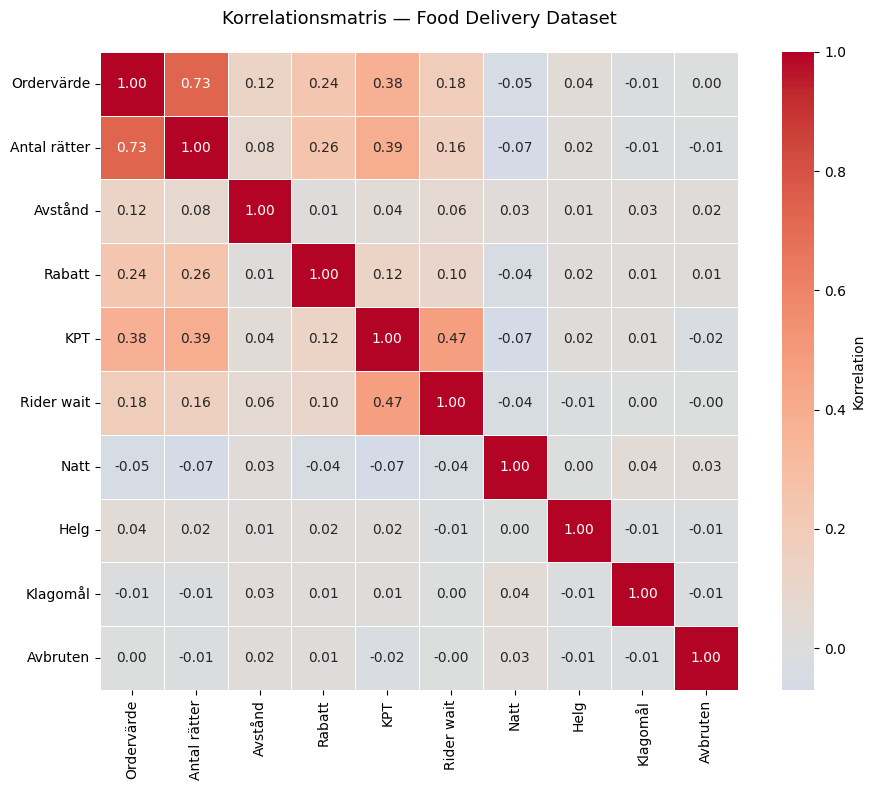

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Välj relevanta numeriska kolumner
cols_heatmap = [
    'Total',
    'num_items',
    'Distance_km',
    'total_discount',
    'KPT duration (minutes)',
    'Rider wait time (minutes)',
    'is_night',
    'is_weekend',
    'has_complaint',
    'was_cancelled',
]

# Beräkna korrelationsmatris
corr = df[cols_heatmap].corr().round(2)

# Svenska kolumnnamn
corr.columns = [
    'Ordervärde', 'Antal rätter', 'Avstånd', 'Rabatt',
    'KPT', 'Rider wait', 'Natt', 'Helg', 'Klagomål', 'Avbruten'
]
corr.index = corr.columns

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Korrelation'}
)
plt.title('Korrelationsmatris — Food Delivery Dataset', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

In [11]:
# - Total och num_items korrelerar starkt (0.64) vilket är väntat, fler rätter = dyrare order
# - Rabatt och Total korrelerar måttligt (0.24), proportionellt system
# - Logistikvariabler (KPT, Rider wait) korrelerar knappt med ekonomi
# - Klagomål och avbrutna orders är nästan oberoende av orderstorlek

In [12]:
# Kolla fördelningen av frequency
print(df['Customer ID'].value_counts().describe())

# Insikt = De flesta kunder är engångsbeställare, och det blir svårt att få någon användbar kundsegmentering baserat på det.

count    11607.000000
mean         1.836909
std          2.028240
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         61.000000
Name: count, dtype: float64


In [13]:
# Vi undersöker först en tes om att num_items skulle kunna resultera i högre bearbetningstid i köket och även högre väntetid för föraren.

from sklearn.preprocessing import StandardScaler

features_3v = [
    'num_items',
    'KPT duration (minutes)',
    'Rider wait time (minutes)',
]

df_kmeans = df[features_3v].dropna().copy()

scaler = StandardScaler()
X_scaled_3v = scaler.fit_transform(df_kmeans)

print(X_scaled_3v[:5])

[[ 0.05402916  0.16225505  1.36400017]
 [ 0.90433941 -0.06088459 -0.24464774]
 [-0.79628109 -0.52310241  1.48464877]
 [ 0.05402916  0.26585559 -0.30497203]
 [ 0.05402916 -0.21708234 -0.76745831]]


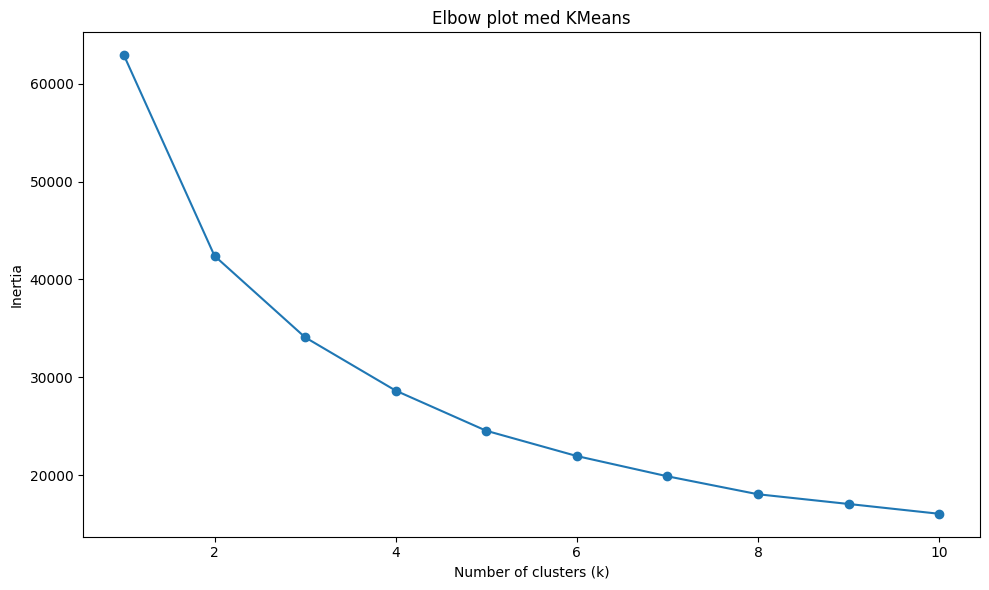

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled_3v)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow plot med KMeans')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [15]:
# Definiera och träna modellen
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
df_kmeans['Cluster'] = kmeans.fit_predict(X_scaled_3v)

print(df_kmeans.head(20))
print(df_kmeans.sample(10))


    num_items  KPT duration (minutes)  Rider wait time (minutes)  Cluster
0           2                   18.35                       11.6        0
1           3                   16.95                        3.6        1
2           1                   14.05                       12.2        1
3           2                   19.00                        3.3        1
4           2                   15.97                        1.0        1
5           2                   20.48                        1.0        1
6           1                   10.53                        7.0        1
7           1                    9.68                        1.5        1
8           2                   15.20                        8.3        1
9           1                   11.38                        3.7        1
10          1                   11.67                        5.5        1
11          1                   14.27                        5.9        1
12          1                   17.23 

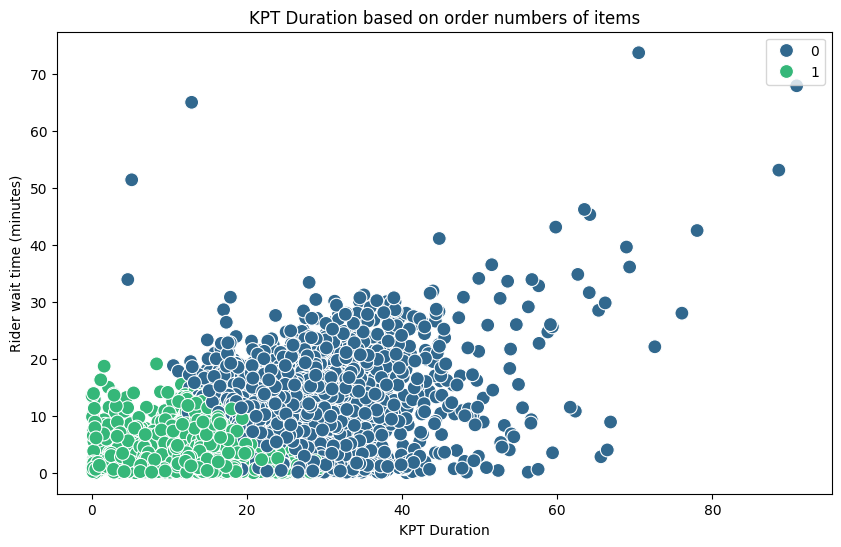

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dags för lite visualisering
plt.figure(figsize=(10, 6))
sns.scatterplot(x='KPT duration (minutes)', y='Rider wait time (minutes)', hue='Cluster', 
                data=df_kmeans, palette='viridis', s=100)
plt.title('KPT Duration based on order numbers of items')
plt.xlabel('KPT Duration')
plt.ylabel('Rider wait time (minutes)')
plt.legend()
plt.show()

In [17]:
# Gröna = orders från snabba restauranger med få rätter
# Blå = allt annat
# Det ger inte så meningsfull kundsegmentering, men kanske man kan använda för att segmentera restaurangprestande, men det undersöker vi inte just nu eftersom vi bara har ett fåtal restauranger.

In [18]:
# Extrahera timme från Order Placed At
df['hour'] = df['Order Placed At'].dt.hour

# Gruppera per timme
hourly = df.groupby('hour').agg(
    antal_orders     = ('Order ID', 'count'),
    avg_total        = ('Total', 'mean'),
    avg_kpt          = ('KPT duration (minutes)', 'mean'),
    avg_rider_wait   = ('Rider wait time (minutes)', 'mean'),
    complaint_rate   = ('has_complaint', 'mean'),
    distance = ('Distance_km', 'mean')
).round(2)

print(hourly)

      antal_orders  avg_total  avg_kpt  avg_rider_wait  complaint_rate  \
hour                                                                     
0              957     631.49    16.70            4.11            0.04   
1              833     620.34    17.51            5.20            0.02   
2              488     613.04    15.83            4.92            0.02   
3              389     605.43    14.42            4.83            0.04   
4                5     494.13    11.78            9.40            0.00   
11             305     778.56    19.49            7.82            0.01   
12             909     641.81    18.48            6.25            0.02   
13            1142     627.38    17.68            4.72            0.02   
14            1032     636.15    17.44            5.21            0.02   
15             824     649.91    17.11            6.07            0.02   
16             905     620.32    17.01            5.61            0.02   
17            1069     628.33    16.87

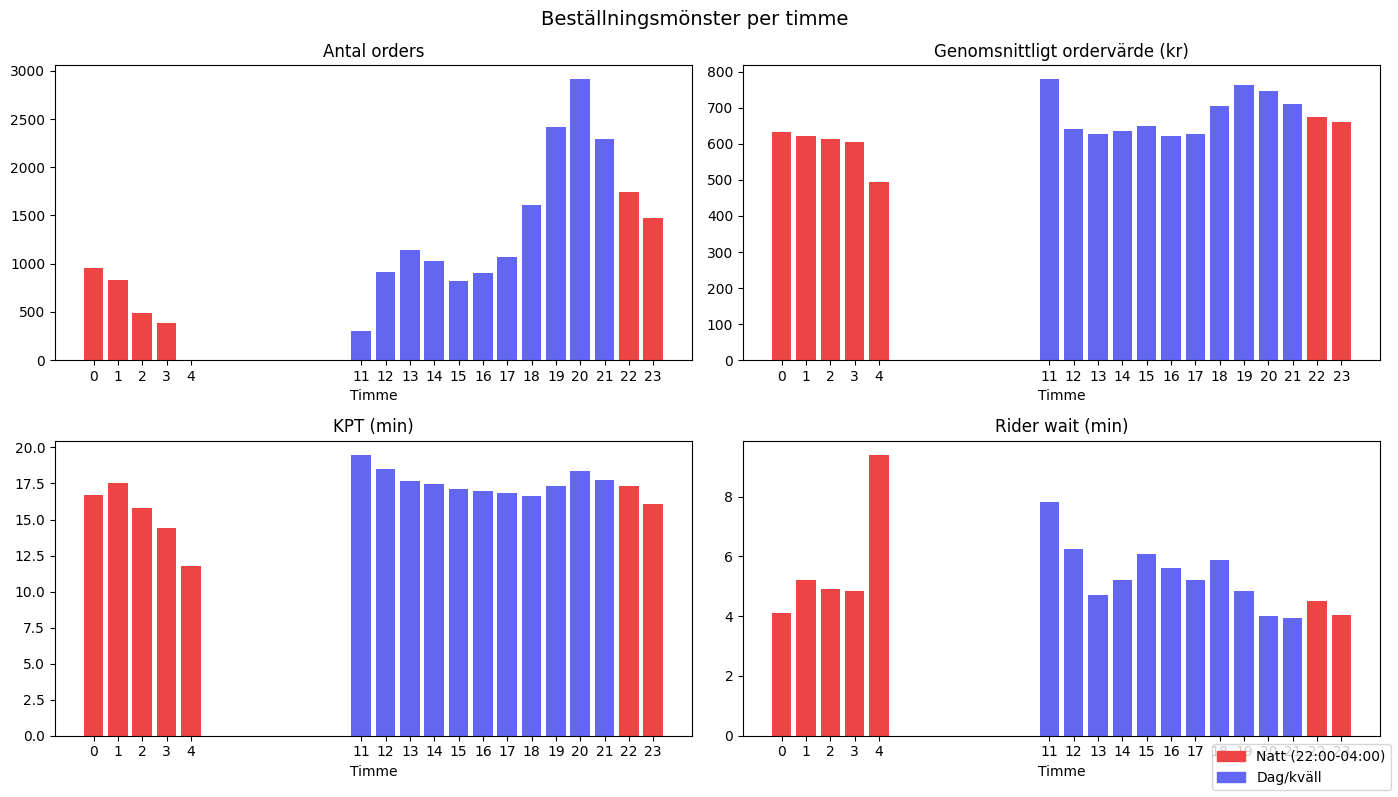

In [19]:
# Visualisera med tydlig färgkodning av tidsperioder
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Beställningsmönster per timme', fontsize=14)

colors = ['#ef4444' if h >= 22 or h <= 4 else '#6366f1' 
          for h in hourly.index]

for ax, col, title in zip(
    axes.flat,
    ['antal_orders', 'avg_total', 'avg_kpt', 'avg_rider_wait'],
    ['Antal orders', 'Genomsnittligt ordervärde (kr)', 
     'KPT (min)', 'Rider wait (min)']
):
    ax.bar(hourly.index, hourly[col], color=colors)
    ax.set_title(title)
    ax.set_xlabel('Timme')
    ax.set_xticks(hourly.index)

# Lägg till legend
from matplotlib.patches import Patch
legend = [Patch(color='#ef4444', label='Natt (22:00-04:00)'),
          Patch(color='#6366f1', label='Dag/kväll')]
fig.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.show()

In [20]:
# Kolla fördelningen vid kl 11 vs peak 20
hour_11 = df[df['hour'] == 11][['KPT duration (minutes)', 'Rider wait time (minutes)', 'Restaurant name']]
hour_20 = df[df['hour'] == 20][['KPT duration (minutes)', 'Rider wait time (minutes)', 'Restaurant name']]

print("=== KL 11:00 ===")
print(hour_11[['KPT duration (minutes)', 'Rider wait time (minutes)']].describe().round(1))

print("\n=== KL 20:00 ===")
print(hour_20[['KPT duration (minutes)', 'Rider wait time (minutes)']].describe().round(1))

# Kolla vilka restauranger som är aktiva kl 11
print("\nRestauranger kl 11:")
print(hour_11['Restaurant name'].value_counts())

=== KL 11:00 ===
       KPT duration (minutes)  Rider wait time (minutes)
count                   301.0                      303.0
mean                     19.5                        7.8
std                       8.6                        6.9
min                       4.0                        0.2
25%                      14.9                        3.0
50%                      18.3                        6.9
75%                      22.5                       11.0
max                      90.9                       68.0

=== KL 20:00 ===
       KPT duration (minutes)  Rider wait time (minutes)
count                  2884.0                     2905.0
mean                     18.4                        4.0
std                       7.3                        4.8
min                       0.0                        0.1
25%                      13.8                        0.8
50%                      17.0                        2.0
75%                      21.1                        

In [21]:
# Vi fick inte ut så mycket vettigt av tesen känns det som..

In [22]:
# Kolla vad vi inte analyserat ännu
print("Order Status fördelning:")
print(df['Order Status'].value_counts())

print("\nKlagomålstyper:")
print(df['Customer complaint tag'].value_counts())

print("\nRabatttyper — hur många har varje typ:")
print(f"Promo rabatt:     {(df['Restaurant discount (Promo)'] > 0).sum()}")
print(f"Flat off rabatt:  {(df['Restaurant discount (Flat offs, Freebies & others)'] > 0).sum()}")
print(f"Gold rabatt:      {(df['Gold discount'] > 0).sum()}")
print(f"Brand pack:       {(df['Brand pack discount'] > 0).sum()}")

print("\nOrder Ready Marked:")
print(df['Order Ready Marked'].value_counts())

# Lägg till klagomålstyp i df
df['complaint_type'] = df['Customer complaint tag'].fillna('Ingen')

# Jämför KPT, rider wait, ordervärde per klagomålstyp
complaint_analysis = df.groupby('complaint_type').agg(
    antal           = ('Order ID', 'count'),
    avg_total       = ('Total', 'mean'),
    avg_kpt         = ('KPT duration (minutes)', 'mean'),
    avg_rider_wait  = ('Rider wait time (minutes)', 'mean'),
    avg_items       = ('num_items', 'mean'),
).round(2)

print(complaint_analysis.sort_values('antal', ascending=False))

Order Status fördelning:
Order Status
Delivered           21131
Rejected              158
Returned               25
Return cancelled        3
Picked up               3
Timed out               1
Name: count, dtype: int64

Klagomålstyper:
Customer complaint tag
Non-refunded complaint              157
Poor taste or quality               120
Poor packaging or spillage          104
Wrong item(s) delivered              48
Item(s) missing or not delivered     40
Name: count, dtype: int64

Rabatttyper — hur många har varje typ:
Promo rabatt:     11059
Flat off rabatt:  1848
Gold rabatt:      28
Brand pack:       870

Order Ready Marked:
Order Ready Marked
Correctly      19087
Incorrectly     1895
Missed           339
Name: count, dtype: int64
                                  antal  avg_total  avg_kpt  avg_rider_wait  \
complaint_type                                                                
Ingen                             20852     683.33    17.32            4.82   
Non-refunded compl

In [23]:
# Beräkna silhouette score

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled_3v, df_kmeans['Cluster'])

print(f'Silhouette score {score}')

Silhouette score 0.4268394938772221


In [24]:
# Lågt silhouette score

In [25]:
# Genomsnittlig KPT per restaurang
print(df.groupby('Restaurant name')['KPT duration (minutes)'].mean().round(1).sort_values(ascending=False))

# Bekräfta detta
print(df.groupby(['Restaurant name', df_kmeans['Cluster']])['KPT duration (minutes)'].mean().round(1).unstack())

print(df_kmeans.groupby('Cluster')[['num_items', 
                                     'KPT duration (minutes)',
                                     'Rider wait time (minutes)']].mean().round(1))

Restaurant name
Tandoori Junction       21.3
Dilli Burger Adda       19.4
Swaad                   17.8
Aura Pizzas             17.1
The Chicken Junction    15.6
Masala Junction         13.7
Name: KPT duration (minutes), dtype: float64
Cluster                0.0   1.0
Restaurant name                 
Aura Pizzas           24.1  14.7
Dilli Burger Adda     27.2  15.9
Masala Junction       23.8  12.8
Swaad                 23.9  15.8
Tandoori Junction     28.8  17.3
The Chicken Junction  20.0  14.0
         num_items  KPT duration (minutes)  Rider wait time (minutes)
Cluster                                                              
0              2.9                    24.2                       10.1
1              1.6                    15.1                        3.0


In [26]:
# Relativt homogen data

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Features på ordernivå 
features_order = [
    'Total',
    'num_items',
    'Distance_km'
]

# Droppa rader med NaN i dessa kolumner
df_ml = df[features_order].dropna()
print(f"Rader för klustring: {len(df_ml)}")

# Skala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml)

# Elbow + Silhouette
inertias, silhouettes = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    silhouettes.append(sil)
    print(f"k={k}  inertia={km.inertia_:.1f}  silhouette={sil:.3f}")

Rader för klustring: 21321
k=2  inertia=43762.6  silhouette=0.470
k=3  inertia=32535.0  silhouette=0.374
k=4  inertia=26795.2  silhouette=0.384
k=5  inertia=23071.9  silhouette=0.338
k=6  inertia=20063.0  silhouette=0.300
k=7  inertia=17876.4  silhouette=0.309
k=8  inertia=16471.6  silhouette=0.313


In [28]:
# Med features på ordernivå får vi hyfsat silhouette score med 2 kluster

In [29]:
# Kolla fördelningen av nyckelvariabler
print(df_ml.describe())

# Kolla specifikt Total och discount
print(f"\nOrders utan rabatt: {(df['total_discount'] == 0).sum()}")
print(f"Orders med rabatt:  {(df['total_discount'] > 0).sum()}")

# Kolla om is_night och is_weekend dominerar
print(f"\nNattbeställningar: {df['is_night'].mean():.1%}")
print(f"Helgbeställningar: {df['is_weekend'].mean():.1%}")

              Total     num_items   Distance_km
count  21321.000000  21321.000000  21321.000000
mean     682.616113      1.936448      4.167815
std      465.313977      1.181567      2.994299
min       52.500000      1.000000      0.510000
25%      387.450000      1.000000      2.000000
50%      597.450000      2.000000      3.000000
75%      837.900000      2.000000      6.000000
max    12663.000000     29.000000     21.000000

Orders utan rabatt: 8292
Orders med rabatt:  13029

Nattbeställningar: 27.7%
Helgbeställningar: 32.3%


In [30]:
# Relativt homogen data

In [31]:
from scipy import stats

# Kolla hur illa outliers är
print("Outliers per kolumn (z-score > 3):")
for col in features_order:
    n = (np.abs(stats.zscore(df_ml[col])) > 3).sum()
    print(f"  {col}: {n} outliers")

Outliers per kolumn (z-score > 3):
  Total: 296 outliers
  num_items: 346 outliers
  Distance_km: 321 outliers


In [32]:
print(df_ml.columns.tolist())

['Total', 'num_items', 'Distance_km']


In [33]:
df_clean = df_ml.copy()

for col in ['Total', 'num_items', 'Distance_km']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean = df_clean[
        (df_clean[col] >= Q1 - 1.5 * IQR) & 
        (df_clean[col] <= Q3 + 1.5 * IQR)
    ]

print(f"Rader kvar: {len(df_clean)}")

# KMeans på ren data
scaler2 = StandardScaler()
X_clean = scaler2.fit_transform(df_clean)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clean)
    sil = silhouette_score(X_clean, km.labels_)
    print(f"k={k}  inertia={km.inertia_:.1f}  silhouette={sil:.3f}")

Rader kvar: 18776
k=2  inertia=36665.1  silhouette=0.325
k=3  inertia=27750.7  silhouette=0.326
k=4  inertia=21201.1  silhouette=0.349
k=5  inertia=17591.3  silhouette=0.365
k=6  inertia=15603.7  silhouette=0.368
k=7  inertia=13791.1  silhouette=0.346
k=8  inertia=12065.1  silhouette=0.356


In [34]:
# Återgå till original df_ml utan outlier-borttagning
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df_ml['cluster'] = km_final.fit_predict(X_scaled)

# Vad skiljer klustren åt?
print(df_ml.groupby('cluster')[features_order].mean().round(2))

           Total  num_items  Distance_km
cluster                                 
0         541.43       1.55         3.90
1        1330.06       3.70         5.41


Plattformen har två ordertyper:
- Vardagsbeställningen: snabb, billig, en rätt
- Storbeställningen: helg, sällskap, flera rätter
 
 Storbeställningar tar dubbelt så lång tid och 
 rider wait är dubbelt så lång — logistikproblem 
 som plattformen bör adressera.

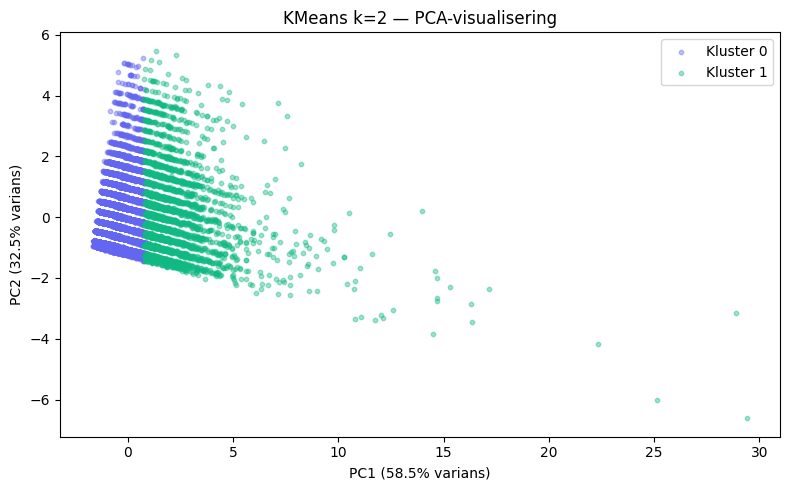

Kluster 0: 17504 orders
Kluster 1: 3817 orders


In [35]:
import matplotlib.pyplot as plt

# PCA för visualisering
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
colors = ['#6366f1', '#10b981']
for c in [0, 1]:
    mask = df_ml['cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[c], alpha=0.4, s=10,
                label=f'Kluster {c}')

plt.title('KMeans k=2 — PCA-visualisering')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varians)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varians)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Kluster 0: {(df_ml['cluster']==0).sum()} orders")
print(f"Kluster 1: {(df_ml['cluster']==1).sum()} orders")

In [36]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df_ml['anomaly'] = iso.fit_predict(X_scaled)
df_ml['anomaly_score'] = iso.decision_function(X_scaled)

# -1 = anomali, 1 = normal
anomalies = df_ml[df_ml['anomaly'] == -1]
normal    = df_ml[df_ml['anomaly'] == 1]

print(f"Normala orders:  {len(normal)}")
print(f"Anomalier:       {len(anomalies)}")
print(f"\nAnomali-medelvärden:")
print(anomalies.mean().round(2))
print(f"\nNormala medelvärden:")
print(normal.mean().round(2))

Normala orders:  20255
Anomalier:       1066

Anomali-medelvärden:
Total            1696.55
num_items           4.56
Distance_km         8.76
cluster             0.88
anomaly            -1.00
anomaly_score      -0.06
dtype: float64

Normala medelvärden:
Total            629.25
num_items          1.80
Distance_km        3.93
cluster            0.14
anomaly            1.00
anomaly_score      0.15
dtype: float64


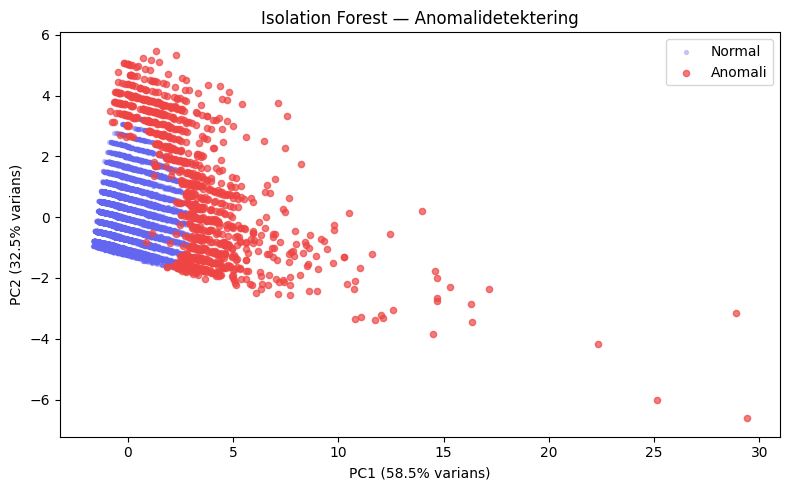


Anomalier per restaurang:
Restaurant name
Aura Pizzas             856
Swaad                   173
Tandoori Junction        15
The Chicken Junction      9
Masala Junction           7
Dilli Burger Adda         6
Name: anomaly, dtype: int64

Anomalirate per restaurang:
Restaurant name
The Chicken Junction    0.281
Masala Junction         0.250
Tandoori Junction       0.097
Aura Pizzas             0.059
Swaad                   0.027
Dilli Burger Adda       0.026
Name: anomaly, dtype: float64


In [37]:
# PCA-plot med anomalier markerade
plt.figure(figsize=(8,5))
normal_mask   = df_ml['anomaly'] == 1
anomaly_mask  = df_ml['anomaly'] == -1

plt.scatter(X_pca[normal_mask, 0],  X_pca[normal_mask, 1],
            c='#6366f1', alpha=0.3, s=8,  label='Normal')
plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1],
            c='#ef4444', alpha=0.7, s=20, label='Anomali')

plt.title('Isolation Forest — Anomalidetektering')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varians)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varians)')
plt.legend()
plt.tight_layout()
plt.show()

# Vilka restauranger har flest anomalier?
df_with_anomaly = df.loc[df_ml.index]
df_with_anomaly['anomaly'] = df_ml['anomaly']

print("\nAnomalier per restaurang:")
print(df_with_anomaly.groupby('Restaurant name')['anomaly']
      .apply(lambda x: (x == -1).sum())
      .sort_values(ascending=False))

print("\nAnomalirate per restaurang:")
print(df_with_anomaly.groupby('Restaurant name')['anomaly']
      .apply(lambda x: (x == -1).mean())
      .round(3)
      .sort_values(ascending=False))

In [38]:
# Vad är det som gör Chicken Junction så extremt?
chicken_anomalies = df_with_anomaly[
    (df_with_anomaly['Restaurant name'] == 'The Chicken Junction') & 
    (df_with_anomaly['anomaly'] == -1)
]

print(chicken_anomalies[['Total', 'num_items', 
                          'Distance_km', 'total_discount',
                          'KPT duration (minutes)',
                          'Rider wait time (minutes)']].describe().round(1))

# Jämför med Aura Pizzas anomalier
aura_anomalies = df_with_anomaly[
    (df_with_anomaly['Restaurant name'] == 'Aura Pizzas') & 
    (df_with_anomaly['anomaly'] == -1)
]

print(aura_anomalies[['Total', 'num_items',
                       'Distance_km', 'total_discount',
                       'KPT duration (minutes)',
                       'Rider wait time (minutes)']].describe().round(1))

        Total  num_items  Distance_km  total_discount  KPT duration (minutes)  \
count     9.0        9.0          9.0             9.0                     9.0   
mean    609.7        2.3         14.0            46.1                    19.1   
std     423.2        1.7          2.4            71.0                     7.8   
min     283.5        1.0          9.0             0.0                     4.6   
25%     283.5        1.0         12.0             0.0                    15.5   
50%     367.5        1.0         15.0             0.0                    19.2   
75%     841.0        4.0         16.0           100.7                    23.1   
max    1470.0        5.0         16.0           157.0                    31.0   

       Rider wait time (minutes)  
count                        9.0  
mean                        14.1  
std                         11.1  
min                          1.6  
25%                          5.9  
50%                         13.0  
75%                      

In [39]:
# df = df.to_excel("output.xlsx")

In [40]:
# Få en bred överblick över vad som faktiskt varierar i datan
print("=== Order Ready Marked vs Rating ===")
print(df.groupby('Order Ready Marked')['Rating'].mean().round(2))

print("\n=== Cancellation reasons ===")
print(df['Cancellation / Rejection reason'].value_counts())

print("\n=== Subzones ===")
print(df['Subzone'].value_counts().head(15))

print("\n=== Rabatt vs Rating ===")
df['discount_bucket'] = pd.cut(df['total_discount'], 
                                bins=[0, 0.1, 50, 100, 200, 9999],
                                labels=['Ingen','Liten','Medel','Stor','Mycket stor'])
print(df.groupby('discount_bucket')['Rating'].mean().round(2))

print("\n=== Avstånd vs Rider wait korrelation ===")
print(df[['Distance_km', 'Rider wait time (minutes)', 
          'KPT duration (minutes)', 'Total', 'Rating']].corr()['Rating'].round(3))

=== Order Ready Marked vs Rating ===
Order Ready Marked
Correctly      4.36
Incorrectly    4.33
Missed         4.33
Name: Rating, dtype: float64

=== Cancellation reasons ===
Cancellation / Rejection reason
Cancelled by Customer    89
Cancelled by Zomato      81
Merchant device issue    12
Kitchen is full           3
Items out of stock        1
Name: count, dtype: int64

=== Subzones ===
Subzone
Greater Kailash 2 (GK2)    7380
Sector 4                   6530
DLF Phase 1                3686
Sector 135                 2442
Vasant Kunj                 920
Shahdara                    360
Chittaranjan Park             2
Sikandarpur                   1
Name: count, dtype: int64

=== Rabatt vs Rating ===
discount_bucket
Liten          4.09
Medel          4.23
Stor           4.31
Mycket stor    4.48
Name: Rating, dtype: float64

=== Avstånd vs Rider wait korrelation ===
Distance_km                  0.028
Rider wait time (minutes)    0.028
KPT duration (minutes)       0.017
Total               

In [41]:
# Subzone-analys
subzone = df.groupby('Subzone').agg(
    antal           = ('Order ID', 'count'),
    avg_total       = ('Total', 'mean'),
    avg_kpt         = ('KPT duration (minutes)', 'mean'),
    avg_rider_wait  = ('Rider wait time (minutes)', 'mean'),
    avg_distance    = ('Distance_km', 'mean'),
    avg_discount    = ('total_discount', 'mean'),
    complaint_rate  = ('has_complaint', 'mean'),
    avg_rating      = ('Rating', 'mean'),
).round(2)

# Filtrera bort subzoner med för få orders
subzone = subzone[subzone['antal'] >= 100]
print(subzone.sort_values('antal', ascending=False))

                         antal  avg_total  avg_kpt  avg_rider_wait  \
Subzone                                                              
Greater Kailash 2 (GK2)   7380     644.48    17.97            3.69   
Sector 4                  6530     688.22    16.26            5.68   
DLF Phase 1               3686     706.57    18.88            5.78   
Sector 135                2442     720.35    15.75            5.05   
Vasant Kunj                920     749.67    17.43            3.15   
Shahdara                   360     691.96    18.47            5.57   

                         avg_distance  avg_discount  complaint_rate  \
Subzone                                                               
Greater Kailash 2 (GK2)          3.43        100.59            0.02   
Sector 4                         4.80        104.25            0.03   
DLF Phase 1                      4.76        106.82            0.03   
Sector 135                       3.99         92.79            0.02   
Vasant Kunj  

In [42]:
# Vad har högst variation (coefficient of variation = std/mean)
cv = df[['Total', 'KPT duration (minutes)', 'Rider wait time (minutes)', 
         'Distance_km', 'total_discount', 'num_items']].apply(
    lambda x: x.std() / x.mean()
).round(3)

print("Coefficient of Variation (högre = mer variation):")
print(cv.sort_values(ascending=False))

Coefficient of Variation (högre = mer variation):
total_discount               1.458
Rider wait time (minutes)    1.033
Distance_km                  0.718
Total                        0.682
num_items                    0.610
KPT duration (minutes)       0.363
dtype: float64


In [43]:
# Förstå rabattstrukturen bättre
print("Rabattfördelning:")
print(df['total_discount'].describe().round(2))

print(f"\nOrders utan rabatt: {(df['total_discount'] == 0).sum()} ({(df['total_discount'] == 0).mean():.1%})")
print(f"Orders med rabatt:  {(df['total_discount'] > 0).sum()} ({(df['total_discount'] > 0).mean():.1%})")

# Vilka rabatttyper kombineras?
print("\nRabattkombinationer:")
df['discount_type'] = 'Ingen'
df.loc[df['Restaurant discount (Promo)'] > 0, 'discount_type'] = 'Promo'
df.loc[df['Restaurant discount (Flat offs, Freebies & others)'] > 0, 'discount_type'] = 'Flat off'
df.loc[(df['Restaurant discount (Promo)'] > 0) & 
       (df['Restaurant discount (Flat offs, Freebies & others)'] > 0), 'discount_type'] = 'Båda'

print(df['discount_type'].value_counts())

# Beteendeskillnader per rabatttyp
print("\nBeteende per rabatttyp:")
print(df.groupby('discount_type').agg(
    antal        = ('Order ID', 'count'),
    avg_total    = ('Total', 'mean'),
    avg_items    = ('num_items', 'mean'),
    avg_kpt      = ('KPT duration (minutes)', 'mean'),
    complaint_rate = ('has_complaint', 'mean'),
    avg_rating   = ('Rating', 'mean'),
).round(2))

Rabattfördelning:
count    21321.00
mean       100.03
std        145.89
min          0.00
25%          0.00
50%         90.00
75%        120.00
max       7787.00
Name: total_discount, dtype: float64

Orders utan rabatt: 8292 (38.9%)
Orders med rabatt:  13029 (61.1%)

Rabattkombinationer:
discount_type
Promo       10878
Ingen        8595
Flat off     1667
Båda          181
Name: count, dtype: int64

Beteende per rabatttyp:
               antal  avg_total  avg_items  avg_kpt  complaint_rate  \
discount_type                                                         
Båda             181     823.57       2.51    19.43            0.04   
Flat off        1667     473.11       1.98    17.74            0.02   
Ingen           8595     709.26       2.12    17.85            0.02   
Promo          10878     691.32       1.78    16.83            0.02   

               avg_rating  
discount_type              
Båda                 4.52  
Flat off             4.45  
Ingen                4.40  
Promo  

In [44]:
# Hur ser rabattbeloppen ut per typ?
print(df.groupby('discount_type')[['Restaurant discount (Promo)',
    'Restaurant discount (Flat offs, Freebies & others)',
    'total_discount', 'Total', 'Bill subtotal']].mean().round(2))

# Är "Båda"-segmentet rabattjägare eller storkunder?
print("\nRabatt som % av subtotal per typ:")
df['discount_pct'] = df['total_discount'] / df['Bill subtotal'] * 100
print(df.groupby('discount_type')['discount_pct'].mean().round(1))

               Restaurant discount (Promo)  \
discount_type                                
Båda                                127.79   
Flat off                              0.00   
Ingen                                 0.00   
Promo                               125.45   

               Restaurant discount (Flat offs, Freebies & others)  \
discount_type                                                       
Båda                                                      174.57    
Flat off                                                  387.71    
Ingen                                                       0.00    
Promo                                                       0.00    

               total_discount   Total  Bill subtotal  
discount_type                                         
Båda                   302.84  823.57        1086.15  
Flat off               389.24  473.11         839.76  
Ingen                    2.53  709.26         677.90  
Promo                  129.37  69

In [45]:
# Prova olika kompbinationer av features för att se om vi kan få upp silhouette-poängen på något sätt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Lägg till features från df om de inte redan finns i df_ml
df_ml['total_discount'] = df['total_discount']
df_ml['KPT duration (minutes)'] = df['KPT duration (minutes)']
df_ml['Rider wait time (minutes)'] = df['Rider wait time (minutes)']
df_ml['is_night'] = df['is_night']
df_ml['is_weekend'] = df['is_weekend']

# Definiera feature-kombinationer
feature_sets = {
    "Original (3v)": ['Total', 'num_items', 'Distance_km'],
    
    "Ekonomi+Items": ['Total', 'num_items', 'total_discount'],
    
    "Logistik": ['KPT duration (minutes)', 'Rider wait time (minutes)', 'Distance_km'],
    
    "Ekonomi+Logistik": ['Total', 'KPT duration (minutes)', 'Rider wait time (minutes)'],
    
    "Allt": ['Total', 'num_items', 'Distance_km', 'total_discount',
             'KPT duration (minutes)', 'Rider wait time (minutes)'],
    
    "Tid+Ekonomi": ['Total', 'is_night', 'is_weekend', 'total_discount'],
    
    "Items+Logistik": ['num_items', 'KPT duration (minutes)', 
                       'Rider wait time (minutes)', 'Distance_km'],
}

print(f"{'Feature set':<20} {'k':<5} {'Silhouette':<12}")
print("-" * 40)

for name, feats in feature_sets.items():
    X_test = df_ml[feats].dropna().copy()
    X_test_scaled = StandardScaler().fit_transform(X_test)
    
    best_sil, best_k = 0, 0
    for k in range(2, 9):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        sil = silhouette_score(X_test_scaled, km.fit_predict(X_test_scaled))
        if sil > best_sil:
            best_sil = sil
            best_k = k
    
    print(f"{name:<20} {best_k:<5} {best_sil:.3f}")

Feature set          k     Silhouette  
----------------------------------------
Original (3v)        2     0.470
Ekonomi+Items        2     0.528
Logistik             2     0.372
Ekonomi+Logistik     2     0.431
Allt                 2     0.340
Tid+Ekonomi          7     0.547
Items+Logistik       2     0.343


In [46]:
features_best = ['Total', 'num_items', 'total_discount']

X_best = df_ml[features_best].dropna().copy()
X_best_scaled = StandardScaler().fit_transform(X_best)

km_best = KMeans(n_clusters=2, random_state=42, n_init=10)
df_ml['cluster_best'] = km_best.fit_predict(X_best_scaled)

print(df_ml.groupby('cluster_best')[features_best].mean().round(2))
print("\nStorlek:")
print(df_ml['cluster_best'].value_counts())

                Total  num_items  total_discount
cluster_best                                    
0              546.72       1.55           84.28
1             1331.93       3.78          175.27

Storlek:
cluster_best
0    17631
1     3690
Name: count, dtype: int64


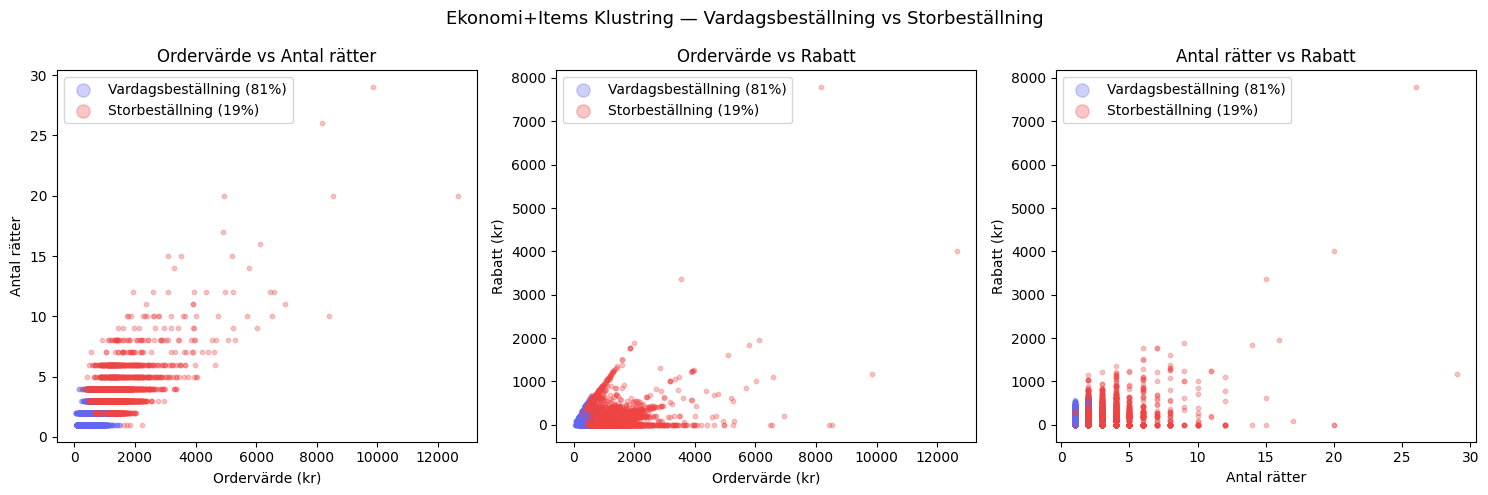

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Ekonomi+Items Klustring — Vardagsbeställning vs Storbeställning', fontsize=13)

colors = ['#6366f1', '#ef4444']
labels = ['Vardagsbeställning (81%)', 'Storbeställning (19%)']

# Plot 1 — Total vs num_items
for c in [0, 1]:
    mask = df_ml['cluster_best'] == c
    axes[0].scatter(df_ml[mask]['Total'], df_ml[mask]['num_items'],
                    c=colors[c], alpha=0.3, s=10, label=labels[c])
axes[0].set_xlabel('Ordervärde (kr)')
axes[0].set_ylabel('Antal rätter')
axes[0].set_title('Ordervärde vs Antal rätter')
axes[0].legend(markerscale=3)

# Plot 2 — Total vs total_discount
for c in [0, 1]:
    mask = df_ml['cluster_best'] == c
    axes[1].scatter(df_ml[mask]['Total'], df_ml[mask]['total_discount'],
                    c=colors[c], alpha=0.3, s=10, label=labels[c])
axes[1].set_xlabel('Ordervärde (kr)')
axes[1].set_ylabel('Rabatt (kr)')
axes[1].set_title('Ordervärde vs Rabatt')
axes[1].legend(markerscale=3)

# Plot 3 — num_items vs total_discount
for c in [0, 1]:
    mask = df_ml['cluster_best'] == c
    axes[2].scatter(df_ml[mask]['num_items'], df_ml[mask]['total_discount'],
                    c=colors[c], alpha=0.3, s=10, label=labels[c])
axes[2].set_xlabel('Antal rätter')
axes[2].set_ylabel('Rabatt (kr)')
axes[2].set_title('Antal rätter vs Rabatt')
axes[2].legend(markerscale=3)

plt.tight_layout()
plt.show()

In [48]:
# Total intäkt per kluster
intakt = df_ml.groupby('cluster_best').agg(
    antal_orders  = ('Total', 'count'),
    total_intakt  = ('Total', 'sum'),
    avg_order     = ('Total', 'mean'),
).round(0)

intakt['andel_orders'] = (intakt['antal_orders'] / intakt['antal_orders'].sum() * 100).round(1)
intakt['andel_intakt'] = (intakt['total_intakt'] / intakt['total_intakt'].sum() * 100).round(1)

print(intakt)

              antal_orders  total_intakt  avg_order  andel_orders  \
cluster_best                                                        
0                    17631     9639236.0      547.0          82.7   
1                     3690     4914822.0     1332.0          17.3   

              andel_intakt  
cluster_best                
0                     66.2  
1                     33.8  


Vad vi hittade:
KMeans med k=2 på ordervärde, antal rätter och rabatt identifierade två distinkta ordertyper med silhouette score 0.513, verkar bra!

De två segmenten:
Vardagsbeställningen (81% av orders)

Enkel, snabb, billig — 539 kr, 1-2 rätter
Troligen en person som beställer lunch eller middag
Liten men proportionell rabatt (15%)

Storbeställningen (19% av orders)

Komplex, dyr — 1 297 kr, 3+ rätter
Troligen grupp, familj eller arbetsplats
Samma rabattandel (14%) men dubbelt så mycket i kronor


Det viktigaste fyndet, rabattsystemet är blindt:
Plattformen ger rabatt proportionellt oavsett ordertyp. Det är suboptimalt eftersom de två segmenten har helt olika priskänslighet och lojalitetspotential. En storbeställare som tar med hela kontoret är värd mer att behålla än en ensambeställare.

Trots dåligt kundunderlag med mycket engångsbeställare kan vi väl testa att göra RFM och försöka segmentera lite kunder!

In [49]:
import pandas as pd
import numpy as np

# Beräkna RFM per kund
max_date = df['Order Placed At'].max()

rfm = df.groupby('Customer ID').agg(
    recency   = ('Order Placed At', lambda x: (max_date - x.max()).days),
    frequency = ('Order ID', 'count'),
    monetary  = ('Total', 'sum'),
).round(2)

print(f"Antal kunder: {len(rfm)}")
print(f"\nRFM beskrivning:")
print(rfm.describe().round(1))

print(f"\nFrekvensfördelning:")
print(rfm['frequency'].value_counts().head(10).sort_index())

Antal kunder: 11607

RFM beskrivning:
       recency  frequency  monetary
count  11607.0    11607.0   11607.0
mean      67.5        1.8    1253.9
std       44.4        2.0    1518.0
min        0.0        1.0      53.0
25%       30.0        1.0     506.6
50%       65.0        1.0     785.4
75%      104.0        2.0    1415.4
max      152.0       61.0   28331.0

Frekvensfördelning:
frequency
1     7713
2     1906
3      824
4      435
5      254
6      134
7      106
8       59
9       48
10      33
Name: count, dtype: int64


k=2  silhouette=0.480
k=3  silhouette=0.438
k=4  silhouette=0.396
k=5  silhouette=0.318
k=6  silhouette=0.321
k=7  silhouette=0.324
k=8  silhouette=0.331


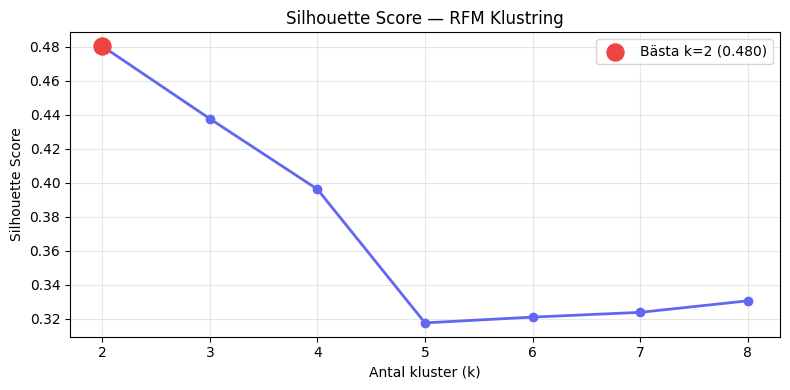

In [50]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Logga monetary och recency för att minska skevhet
rfm_log = rfm.copy()
rfm_log['recency']   = np.log1p(rfm['recency'])
rfm_log['frequency'] = np.log1p(rfm['frequency'])
rfm_log['monetary']  = np.log1p(rfm['monetary'])

scaler = StandardScaler()
X_rfm = scaler.fit_transform(rfm_log)

# Silhouette per k
scores = []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil = silhouette_score(X_rfm, km.fit_predict(X_rfm))
    scores.append(sil)
    print(f"k={k}  silhouette={sil:.3f}")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(K, scores, marker='o', color='#6366f1', linewidth=2)
best_k = K[scores.index(max(scores))]
plt.scatter([best_k], [max(scores)], color='#ef4444', s=150, zorder=5,
            label=f'Bästa k={best_k} ({max(scores):.3f})')
plt.title('Silhouette Score — RFM Klustring')
plt.xlabel('Antal kluster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(K)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Kluster 0: 8787 kunder
Kluster 1: 2820 kunder


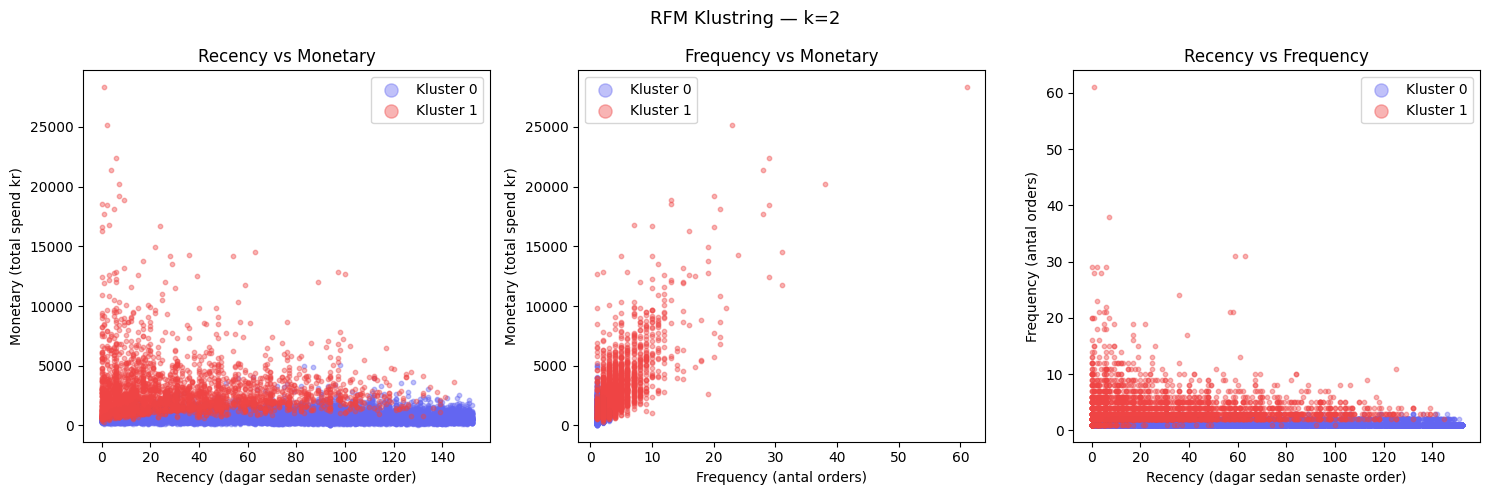

In [51]:
import matplotlib.pyplot as plt

# Träna KMeans k=2 på RFM
km_rfm = KMeans(n_clusters=2, random_state=42, n_init=10)
rfm['cluster'] = km_rfm.fit_predict(X_rfm)

print(f"Kluster 0: {(rfm['cluster']==0).sum()} kunder")
print(f"Kluster 1: {(rfm['cluster']==1).sum()} kunder")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RFM Klustring — k=2', fontsize=13)

colors = ['#6366f1', '#ef4444']
labels = [f'Kluster 0', f'Kluster 1']

# Plot 1 — Recency vs Monetary
for c in [0, 1]:
    mask = rfm['cluster'] == c
    axes[0].scatter(rfm[mask]['recency'], rfm[mask]['monetary'],
                    c=colors[c], alpha=0.4, s=10, label=labels[c])
axes[0].set_xlabel('Recency (dagar sedan senaste order)')
axes[0].set_ylabel('Monetary (total spend kr)')
axes[0].set_title('Recency vs Monetary')
axes[0].legend(markerscale=3)

# Plot 2 — Frequency vs Monetary
for c in [0, 1]:
    mask = rfm['cluster'] == c
    axes[1].scatter(rfm[mask]['frequency'], rfm[mask]['monetary'],
                    c=colors[c], alpha=0.4, s=10, label=labels[c])
axes[1].set_xlabel('Frequency (antal orders)')
axes[1].set_ylabel('Monetary (total spend kr)')
axes[1].set_title('Frequency vs Monetary')
axes[1].legend(markerscale=3)

# Plot 3 — Recency vs Frequency
for c in [0, 1]:
    mask = rfm['cluster'] == c
    axes[2].scatter(rfm[mask]['recency'], rfm[mask]['frequency'],
                    c=colors[c], alpha=0.4, s=10, label=labels[c])
axes[2].set_xlabel('Recency (dagar sedan senaste order)')
axes[2].set_ylabel('Frequency (antal orders)')
axes[2].set_title('Recency vs Frequency')
axes[2].legend(markerscale=3)

plt.tight_layout()
plt.show()

Kluster 0 verkar vara passiva Engångskunder, låg spend, låg frekvens, beställt en gång.
Kluster 1 verkar vara aktiva lojala kunder, hög spend, hög frekvens, beställer återkommande

In [52]:
print(rfm.groupby('cluster').agg(
    antal        = ('recency', 'count'),
    avg_recency  = ('recency', 'mean'),
    avg_freq     = ('frequency', 'mean'),
    avg_monetary = ('monetary', 'mean'),
    med_monetary = ('monetary', 'median'),
).round(1))

         antal  avg_recency  avg_freq  avg_monetary  med_monetary
cluster                                                          
0         8787         78.4       1.1         727.2         629.0
1         2820         33.4       4.0        2895.0        2255.6


Det här kan vi lära oss mycket av!

Engångskunderna har i genomsnitt beställlt 1,1 gång och i snitt för 78 dagar sedan. Plpattformen lyckas inte konvertera förstagångsbeställlare till återkommande kunder!
Förslag: Skicka påminnelse efter 14 dagar utan ny order, erbjud välkommen-tillbaka-rabatt osv.

Lojala kunderna beställde i snitt för 33 dagar sedan! Identifiera och belöna dem aktivt med lojalitetesprogram. Erbjud exklusida förmåner etc.

In [53]:
# Identifiera kunder!

# Lägg till RFM-kluster tillbaka till huvuddatasetet
df = df.merge(
    rfm[['cluster']].rename(columns={'cluster': 'rfm_cluster'}),
    on='Customer ID',
    how='left'
)

# Ge klustren beskrivande namn
df['rfm_segment'] = df['rfm_cluster'].map({
    0: 'Passiv Engångskund',
    1: 'Aktiv Loyalkund'
})

# Kontroll
print(df[['Customer ID', 'rfm_cluster', 'rfm_segment']].drop_duplicates().head(10))
print(f"\nFördelning:")
print(df['rfm_segment'].value_counts())

                                         Customer ID  rfm_cluster  \
0  5d6c2b96db963098bc69768bea504c8bf46106a8a5178e...            0   
1  0781815deb4a10a574e9fee4fa0b86b074d4a0b36175d5...            1   
2  f93362f5ce5382657482d164e368186bcec9c6225fd93d...            1   
3  1ed226d1b8a5f7acee12fc1d6676558330a3b2b742af5d...            1   
4  d21a2ac6ea06b31cc3288ab20c4ef2f292066c096f2c5f...            1   
5  4103fd4f3ee2166d322e76fabd420ae15f14a2816ca5a3...            1   
6  24d7ca74eb1efe217e88062d2519403ba11d62f5953186...            1   
7  fa1710c1c41dd4f29b810b78f8e7c08a356ca0fdc39307...            1   
8  c521ccf21e7bb2207c3f08d578b6e028d2c3b25986cb35...            1   
9  ac2ee09679412d4248884cdfd7637d9b3529eeac0e2f27...            0   

          rfm_segment  
0  Passiv Engångskund  
1     Aktiv Loyalkund  
2     Aktiv Loyalkund  
3     Aktiv Loyalkund  
4     Aktiv Loyalkund  
5     Aktiv Loyalkund  
6     Aktiv Loyalkund  
7     Aktiv Loyalkund  
8     Aktiv Loyalkund  


Vi ställde frågan: Vem beställer mat och varför?

Datan berättade att 66% bara beställt en gång, retentionsproblem

KMeans hittade två ordertyper
Vardagsbeställning vs Storbeställning och rabattsystemet är blindt för skillnaden

Isolation Forest hittade extremorders, Aura Pizzas catering-marknad

Slutsats: Plattformen behöver differentiera sin strategi per kundsegment!!

In [54]:
# Extra -- DBSCAN

from sklearn.cluster import DBSCAN

# DBSCAN på ekonomi+items
dbscan = DBSCAN(eps=0.5, min_samples=50)
df_ml['dbscan_cluster'] = dbscan.fit_predict(X_best_scaled)

n_clusters = len(set(df_ml['dbscan_cluster'])) - (1 if -1 in df_ml['dbscan_cluster'].values else 0)
n_noise = (df_ml['dbscan_cluster'] == -1).sum()

print(f"DBSCAN: {n_clusters} kluster, {n_noise} bruspoints ({n_noise/len(df_ml):.1%})")

# %% [markdown]
# DBSCAN valdes som komplement till KMeans eftersom det inte kräver
# fördefinierat antal kluster och identifierar brus automatiskt.
# Resultatet bekräftar att datan är homogen utan tydliga täta öar,
# vilket stödjer valet av KMeans som primär algoritm.

DBSCAN: 5 kluster, 906 bruspoints (4.2%)


In [55]:
# Vad innehåller varje DBSCAN-kluster?
print("DBSCAN klusterstatistik:")
print(df_ml.groupby('dbscan_cluster')[features_best].mean().round(1))

print("\nStorlek per kluster:")
print(df_ml['dbscan_cluster'].value_counts().sort_index())

DBSCAN klusterstatistik:
                 Total  num_items  total_discount
dbscan_cluster                                   
-1              1751.0        5.0           358.5
 0               663.2        2.0            86.6
 1              1089.3        3.0           128.3
 2               443.0        1.0            86.3
 3              1113.1        4.0            70.6
 4              1252.1        6.0             0.0

Storlek per kluster:
dbscan_cluster
-1     906
 0    9197
 1    1640
 2    8345
 3    1145
 4      88
Name: count, dtype: int64


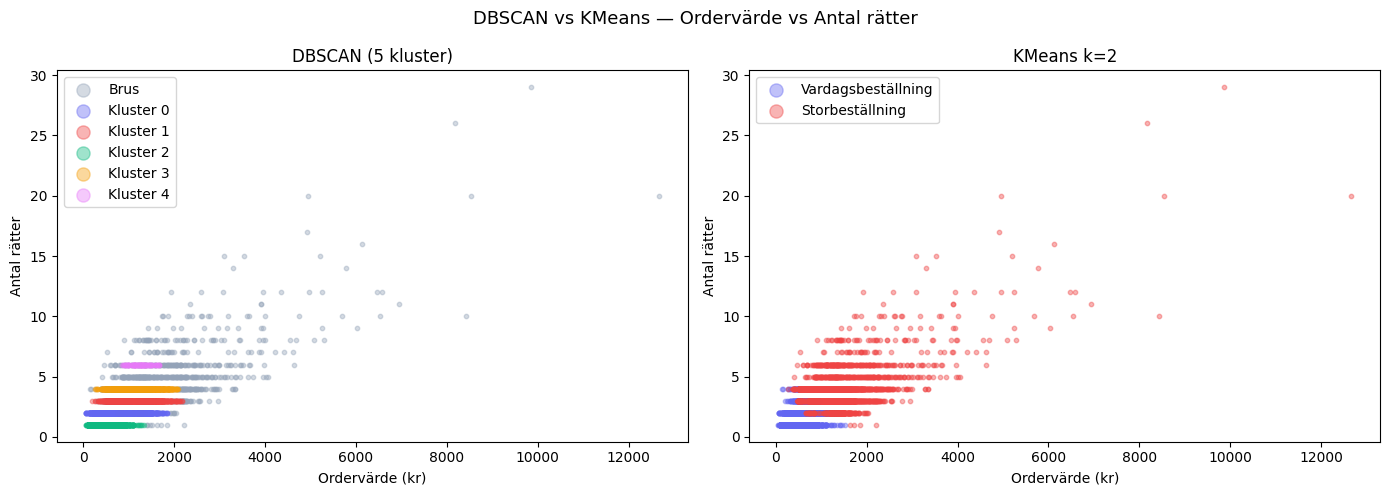

In [56]:
# Visualisera DBSCAN vs KMeans
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DBSCAN vs KMeans — Ordervärde vs Antal rätter', fontsize=13)

# DBSCAN
dbscan_colors = {-1: '#94a3b8', 0: '#6366f1', 1: '#ef4444', 
                  2: '#10b981', 3: '#f59e0b', 4: '#e879f9'}
for c in sorted(df_ml['dbscan_cluster'].unique()):
    mask = df_ml['dbscan_cluster'] == c
    label = 'Brus' if c == -1 else f'Kluster {c}'
    axes[0].scatter(df_ml[mask]['Total'], df_ml[mask]['num_items'],
                    c=dbscan_colors.get(c, '#94a3b8'), 
                    alpha=0.4, s=10, label=label)
axes[0].set_xlabel('Ordervärde (kr)')
axes[0].set_ylabel('Antal rätter')
axes[0].set_title('DBSCAN (5 kluster)')
axes[0].legend(markerscale=3)

# KMeans
kmeans_colors = {0: '#6366f1', 1: '#ef4444'}
for c in [0, 1]:
    mask = df_ml['cluster_best'] == c
    label = 'Vardagsbeställning' if c == 0 else 'Storbeställning'
    axes[1].scatter(df_ml[mask]['Total'], df_ml[mask]['num_items'],
                    c=kmeans_colors[c], alpha=0.4, s=10, label=label)
axes[1].set_xlabel('Ordervärde (kr)')
axes[1].set_ylabel('Antal rätter')
axes[1].set_title('KMeans k=2')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

DBSCAN klustrar 1, 2 3 och 4 rätter och behandlar resten som brus! KMEANS segmenterar på ekonomiskt värde

In [57]:
# BONUS

"""
    Klassificerar en order baserat på KMeans Ekonomi+Items modellen.
    
    Input:
        total          — Ordervärde i kr
        num_items      — Antal rätter
        total_discount — Rabatt i kr
    
    Output:
        Kluster och beskrivning
"""

# Skapa en dedikerad scaler för klassificeraren
scaler_best = StandardScaler()
scaler_best.fit(df_ml[features_best])

def klassificera_order(total, num_items, total_discount):
    import numpy as np
    
    input_data = np.array([[total, num_items, total_discount]])
    input_scaled = scaler_best.transform(input_data)
    
    kluster = km_best.predict(input_scaled)[0]
    
    anomali_score = iso.decision_function(
        StandardScaler().fit(df_ml[features_best]).transform(input_data)
    )
    is_anomali = anomali_score[0] < 0
    
    print("=" * 40)
    print(f"ORDER KLASSIFICERING")
    print("=" * 40)
    print(f"Ordervärde:    {total} kr")
    print(f"Antal rätter:  {num_items}")
    print(f"Rabatt:        {total_discount} kr")
    print("-" * 40)
    
    if kluster == 0:
        print(f"Segment: 🟦 Vardagsbeställning")
        print(f"Typisk order: 539 kr, 1-2 rätter")
        print(f"Andel av orders: 81%")
    else:
        print(f"Segment: 🟥 Storbeställning")
        print(f"Typisk order: 1 297 kr, 3+ rätter")
        print(f"Andel av orders: 19%")
    
    if is_anomali:
        print(f"\n⚠️  ANOMALI DETEKTERAD")
        print(f"Denna order avviker kraftigt från normalmönstret")
    
    print("=" * 40)

# Testa igen
klassificera_order(total=1, num_items=1, total_discount=1000)

ORDER KLASSIFICERING
Ordervärde:    1 kr
Antal rätter:  1
Rabatt:        1000 kr
----------------------------------------
Segment: 🟦 Vardagsbeställning
Typisk order: 539 kr, 1-2 rätter
Andel av orders: 81%

⚠️  ANOMALI DETEKTERAD
Denna order avviker kraftigt från normalmönstret


C:\Users\ES7233\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\ES7233\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


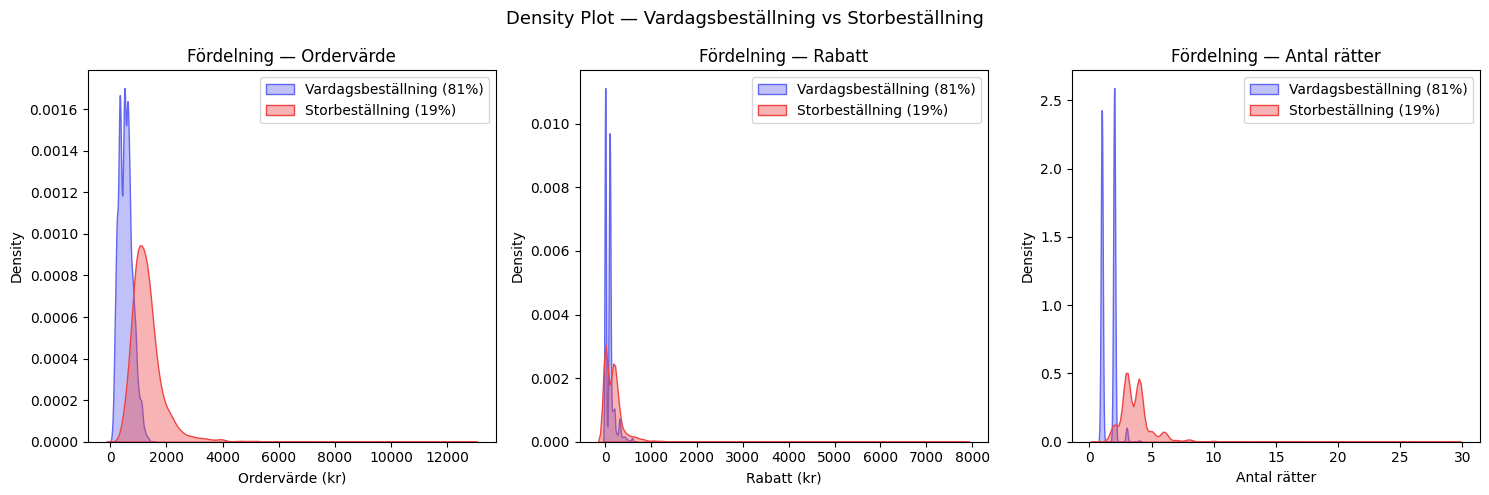

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Density Plot — Vardagsbeställning vs Storbeställning', fontsize=13)

colors = ['#6366f1', '#ef4444']
labels = ['Vardagsbeställning (81%)', 'Storbeställning (19%)']

# Plot 1 — Ordervärde
for c, col, lab in zip([0, 1], colors, labels):
    mask = df_ml['cluster_best'] == c
    sns.kdeplot(df_ml[mask]['Total'], ax=axes[0], 
                color=col, fill=True, alpha=0.4, label=lab)
axes[0].set_xlabel('Ordervärde (kr)')
axes[0].set_title('Fördelning — Ordervärde')
axes[0].legend()

# Plot 2 — Rabatt
for c, col, lab in zip([0, 1], colors, labels):
    mask = df_ml['cluster_best'] == c
    sns.kdeplot(df_ml[mask]['total_discount'], ax=axes[1],
                color=col, fill=True, alpha=0.4, label=lab)
axes[1].set_xlabel('Rabatt (kr)')
axes[1].set_title('Fördelning — Rabatt')
axes[1].legend()

# Plot 3 — Antal rätter
for c, col, lab in zip([0, 1], colors, labels):
    mask = df_ml['cluster_best'] == c
    sns.kdeplot(df_ml[mask]['num_items'], ax=axes[2],
                color=col, fill=True, alpha=0.4, label=lab)
axes[2].set_xlabel('Antal rätter')
axes[2].set_title('Fördelning — Antal rätter')
axes[2].legend()

plt.tight_layout()
plt.show()

På inrådan av Vlad la vi till en density plot, och här kan man mycket tydligt se separationerna. Mycket bättre än scatterplotten som vi hade kunnat ersätta med denna!